In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

# Preprocess Data

In [2]:
years = list(range(2000, 2025))
pdrb_values = [
    19834.575, 20647.9385, 21576.9195, 22623.763, 23777.244,
    25062.0575, 26477.7545, 28071.031, 29670.818, 31406.4275,
    33341.20, 35492.00, 37701.10, 39887.45, 42001.20,
    44183.50, 46460.88, 48819.30, 51372.55, 54204.10,
    52589.05, 54692.30, 57164.80, 59985.12, 62894.50
]

df = pd.DataFrame({
    'Tahun': years,
    'PDRB': pdrb_values
})
df.set_index('Tahun', inplace=True)

print("Data PDRB Jember (ADHK):")
print(df.head())
print(f"\nTotal data: {len(df)} tahun (2000-2024)")

Data PDRB Jember (ADHK):
             PDRB
Tahun            
2000   19834.5750
2001   20647.9385
2002   21576.9195
2003   22623.7630
2004   23777.2440

Total data: 25 tahun (2000-2024)


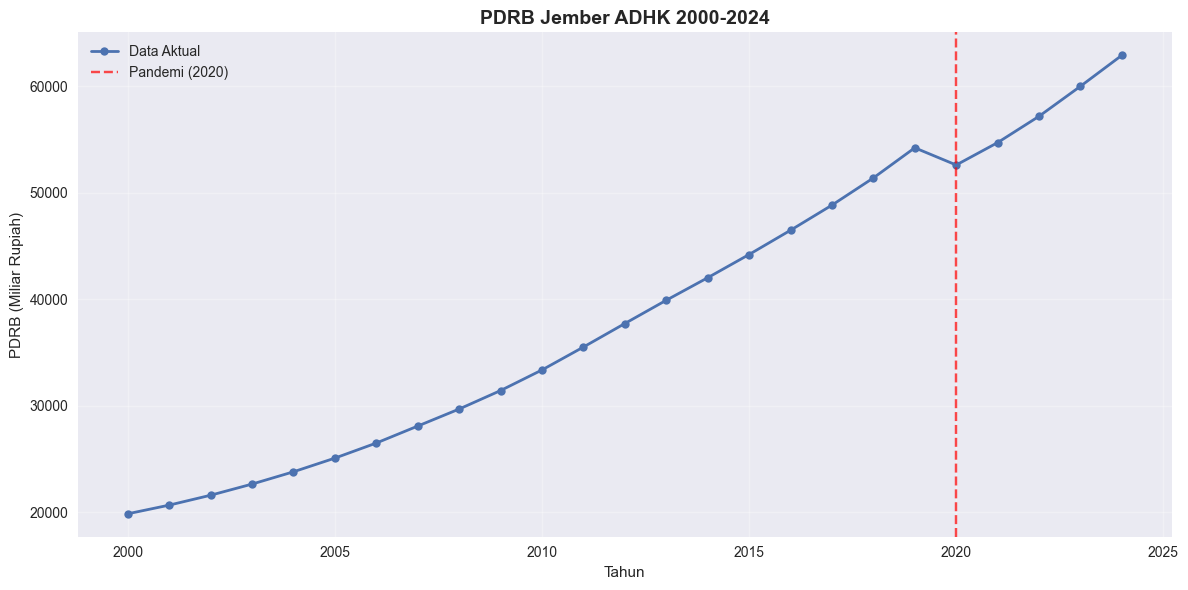

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['PDRB'], marker='o', linewidth=2, markersize=6, label='Data Aktual')
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Pandemi (2020)')
plt.title('PDRB Jember ADHK 2000-2024', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('PDRB (Miliar Rupiah)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Stationer Test

In [4]:
result = adfuller(df['PDRB'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Data memiliki tren (non-stasioner)' if result[1] > 0.05 else 'Data stasioner')

ADF Statistic: -4.3320
p-value: 0.0004
Data stasioner


# Modeling HES

In [5]:
model = Holt(df['PDRB'], exponential=False, damped_trend=False)
fitted_model = model.fit(optimized=True)

# parameter optimal
print("\nParameter Optimal Model Holt:")
print(f"Smoothing Level (α): {fitted_model.params['smoothing_level']:.4f}")
print(f"Smoothing Trend (β) : {fitted_model.params['smoothing_trend']:.4f}")

# MAPE untuk in-sample
def calculate_mape(actual, forecast):
    """Hitung MAPE dengan handling nilai actual = 0"""
    actual, forecast = np.array(actual), np.array(forecast)
    mask = actual != 0 
    mape = np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100
    return mape

mape_insample = calculate_mape(df['PDRB'], fitted_model.fittedvalues)

print(f"\nMAPE (In-Sample 2000-2024): {mape_insample:.2f}%")
print("Interpretasi MAPE:")
if mape_insample < 10:
    print("  → Sangat akurat (<10%)")
elif mape_insample < 20:
    print("  → Baik (10-20%)")
elif mape_insample < 30:
    print("  → Layak (20-30%)")
else:
    print("  → Kurang akurat (>30%)")


Parameter Optimal Model Holt:
Smoothing Level (α): 1.0000
Smoothing Trend (β) : 0.2293

MAPE (In-Sample 2000-2024): 1.62%
Interpretasi MAPE:
  → Sangat akurat (<10%)


In [6]:
# Forecast 5 tahun
forecast_years = 5
forecast = fitted_model.forecast(forecast_years)

# Buat DataFrame forecast
forecast_index = list(range(2025, 2025 + forecast_years))
df_forecast = pd.DataFrame({
    'Tahun': forecast_index,
    'PDRB_Forecast': forecast.values
})
df_forecast.set_index('Tahun', inplace=True)

print("\nHasil Forecast PDRB 2025-2029:")
print(df_forecast.round(2))

# Hitung pertumbuhan tahunan dari 2025-2029
pdrb_2024 = df.loc[2024, 'PDRB']  
growth_2025 = ((df_forecast.iloc[0]['PDRB_Forecast'] - pdrb_2024) / pdrb_2024) * 100

# Pertumbuhan tahun-tahun berikutnya (2026-2029)
forecast_growth = df_forecast['PDRB_Forecast'].pct_change() * 100

print("\nPertumbuhan Tahunan Forecast 2025-2029:")
# Print pertumbuhan 2025
print(f"  {forecast_index[0]}: {growth_2025:.2f}%")

# Print pertumbuhan 2026-2029
for tahun, growth in zip(forecast_index[1:], forecast_growth[1:]):
    print(f"  {tahun}: {growth:.2f}%")

# Hitung rata-rata pertumbuhan 2025-2029
all_growth = [growth_2025] + list(forecast_growth[1:].values)
print(f"Rata-rata pertumbuhan 2025-2029: {np.mean(all_growth):.2f}%")


Hasil Forecast PDRB 2025-2029:
       PDRB_Forecast
Tahun               
2025        65129.31
2026        67364.11
2027        69598.92
2028        71833.73
2029        74068.53

Pertumbuhan Tahunan Forecast 2025-2029:
  2025: 3.55%
  2026: 3.43%
  2027: 3.32%
  2028: 3.21%
  2029: 3.11%
Rata-rata pertumbuhan 2025-2029: 3.32%


## Plot Visual Fit vs Act

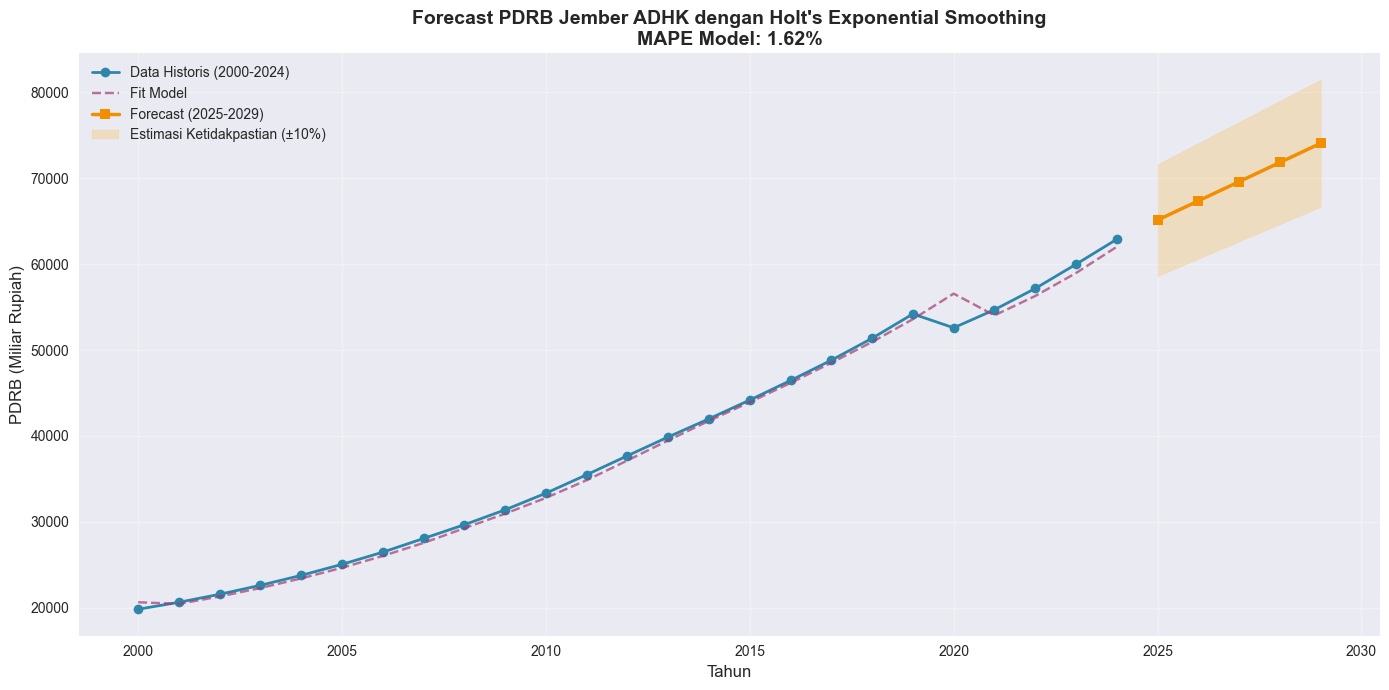

In [7]:
# Plot lengkap dengan MAPE pada judul
plt.figure(figsize=(14, 7))

# Data historis
plt.plot(df.index, df['PDRB'], marker='o', label='Data Historis (2000-2024)', 
         linewidth=2, color='#2E86AB')

# Fit model (in-sample)
plt.plot(df.index, fitted_model.fittedvalues, linestyle='--', 
         label='Fit Model', color='#A23B72', alpha=0.7)

# Forecast
plt.plot(df_forecast.index, df_forecast['PDRB_Forecast'], marker='s', 
         label='Forecast (2025-2029)', linewidth=2.5, color='#F18F01')

# Confidence interval (±10% sebagai estimasi)
confidence_band = 0.10 * df_forecast['PDRB_Forecast']
plt.fill_between(
    df_forecast.index,
    df_forecast['PDRB_Forecast'] - confidence_band,
    df_forecast['PDRB_Forecast'] + confidence_band,
    color='orange', alpha=0.2, label='Estimasi Ketidakpastian (±10%)'
)

plt.title(f'Forecast PDRB Jember ADHK dengan Holt\'s Exponential Smoothing\n'
          f'MAPE Model: {mape_insample:.2f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('PDRB (Miliar Rupiah)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
train = df.loc[:2022]
test = df.loc[2023:]

# Fit model pada data train
model_train = Holt(train['PDRB'], exponential=False).fit(optimized=True)

# Forecast untuk periode test (2 tahun)
test_forecast = model_train.forecast(len(test))

# MAPE data test
mape_test = calculate_mape(test['PDRB'], test_forecast)

print("\nValidasi Model dengan Train-Test Split:")
print(f"Data Train: 2000-2022 ({len(train)} tahun)")
print(f"Data Test : 2023-2024 ({len(test)} tahun)")
print(f"MAPE pada Data Test (2023-2024): {mape_test:.2f}%")
print(f"  → Akurasi forecast 2 tahun terakhir: {100 - mape_test:.2f}%")


print("\nPerbandingan Aktual vs Forecast (Validasi):")
comparison = pd.DataFrame({
    'Tahun': test.index,
    'Aktual': test['PDRB'].values,
    'Forecast': test_forecast.values,
    'Error (%)': np.abs((test['PDRB'].values - test_forecast.values) / test['PDRB'].values) * 100
})
print(comparison.round(2))


Validasi Model dengan Train-Test Split:
Data Train: 2000-2022 (23 tahun)
Data Test : 2023-2024 (2 tahun)
MAPE pada Data Test (2023-2024): 3.12%
  → Akurasi forecast 2 tahun terakhir: 96.88%

Perbandingan Aktual vs Forecast (Validasi):
   Tahun    Aktual  Forecast  Error (%)
0   2023  59985.12  58662.26       2.21
1   2024  62894.50  60352.14       4.04


# SEARCH MODEL

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

In [10]:
years = list(range(2000, 2025))
pdrb_values = [
    19834.575, 20647.9385, 21576.9195, 22623.763, 23777.244,
    25062.0575, 26477.7545, 28071.031, 29670.818, 31406.4275,
    33341.20, 35492.00, 37701.10, 39887.45, 42001.20,
    44183.50, 46460.88, 48819.30, 51372.55, 54204.10,
    52589.05, 54692.30, 57164.80, 59985.12, 62894.50
]

df = pd.DataFrame({
    'Tahun': years,
    'PDRB': pdrb_values
})
df['Tanggal'] = pd.to_datetime(df['Tahun'].astype(str) + '-12-31')
df = df.set_index('Tanggal')

print("Data PDRB ADHK (2000-2024) - Data Terbaru:")
print(df[['Tahun', 'PDRB']].round(2))
print(f"\nTotal data: {len(df)} tahun")

# 2. HITUNG PERSENTASE KENAIKAN TAHUNAN
df['Pertumbuhan (%)'] = df['PDRB'].pct_change() * 100

# Format kolom pertumbuhan dengan highlight negatif/positif
def format_growth(val):
    if pd.isna(val):
        return "-"
    elif val < 0:
        return f"▼ {val:.2f}%"
    else:
        return f"▲ {val:.2f}%"

print("Data PDRB ADHK (2000-2024) dengan Pertumbuhan Tahunan:")
print("="*70)
print(f"{'Tahun':<8} {'PDRB (Miliar Rp)':<25} {'Pertumbuhan (%)':<20}")
print("="*70)

for idx, row in df.iterrows():
    tahun = row['Tahun']
    pdrb = f"Rp {row['PDRB']:,.2f}"
    growth = format_growth(row['Pertumbuhan (%)'])
    print(f"{tahun:<8} {pdrb:<25} {growth:<20}")

print("="*70)

Data PDRB ADHK (2000-2024) - Data Terbaru:
            Tahun      PDRB
Tanggal                    
2000-12-31   2000  19834.58
2001-12-31   2001  20647.94
2002-12-31   2002  21576.92
2003-12-31   2003  22623.76
2004-12-31   2004  23777.24
2005-12-31   2005  25062.06
2006-12-31   2006  26477.75
2007-12-31   2007  28071.03
2008-12-31   2008  29670.82
2009-12-31   2009  31406.43
2010-12-31   2010  33341.20
2011-12-31   2011  35492.00
2012-12-31   2012  37701.10
2013-12-31   2013  39887.45
2014-12-31   2014  42001.20
2015-12-31   2015  44183.50
2016-12-31   2016  46460.88
2017-12-31   2017  48819.30
2018-12-31   2018  51372.55
2019-12-31   2019  54204.10
2020-12-31   2020  52589.05
2021-12-31   2021  54692.30
2022-12-31   2022  57164.80
2023-12-31   2023  59985.12
2024-12-31   2024  62894.50

Total data: 25 tahun
Data PDRB ADHK (2000-2024) dengan Pertumbuhan Tahunan:
Tahun    PDRB (Miliar Rp)          Pertumbuhan (%)     
2000.0   Rp 19,834.58              -                   
2001.0   Rp 

In [11]:
print("\n" + "="*60)
print("UJI STASIONERITAS (ADF TEST)")
print("="*60)
result = adfuller(df['PDRB'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Kesimpulan: Data STASIONER' if result[1] < 0.05 else 'Kesimpulan: Data NON-STASIONER (perlu differencing)')



UJI STASIONERITAS (ADF TEST)
ADF Statistic: -4.3320
p-value: 0.0004
Kesimpulan: Data STASIONER


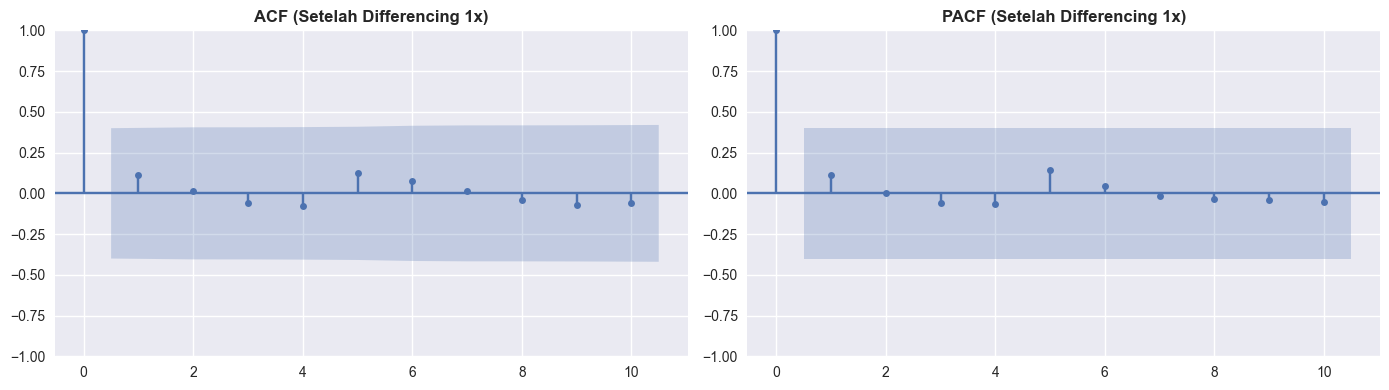

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['PDRB'].diff().dropna(), ax=axes[0], lags=10)
plot_pacf(df['PDRB'].diff().dropna(), ax=axes[1], lags=10)
axes[0].set_title('ACF (Setelah Differencing 1x)', fontsize=12, fontweight='bold')
axes[1].set_title('PACF (Setelah Differencing 1x)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Spliting

In [13]:
train = df.loc[:'2020-12-31']
test = df.loc['2021-12-31':]

print("\n" + "="*60)
print("SPLIT DATA (VALIDASI DIPERLUAS)")
print("="*60)
print(f"Data Train: {train.index.min().year} - {train.index.max().year} ({len(train)} tahun)")
print(f"Data Test : {test.index.min().year} - {test.index.max().year} ({len(test)} tahun)")
print("Catatan: Test set mencakup periode pandemi (2021) dan pemulihan (2022-2024)")


SPLIT DATA (VALIDASI DIPERLUAS)
Data Train: 2000 - 2020 (21 tahun)
Data Test : 2021 - 2024 (4 tahun)
Catatan: Test set mencakup periode pandemi (2021) dan pemulihan (2022-2024)


## MAPE

In [14]:
def calculate_mape(actual, forecast):
    return np.mean(np.abs((actual - forecast) / actual)) * 100

In [ ]:
# 9. Perbandingan Semua Model
print("\n" + "="*70)
print("PERBANDINGAN KINERJA MODEL (MAPE pada 2021-2024)")
print("="*70)
# Assign a value to mape_adjusted (replace np.nan with the actual value if available)
mape_adjusted = np.nan

models_comparison = pd.DataFrame({
    'Model': [
        'ARIMA(0,1,1)+Drift',
        'Holt\'s Linear Trend',
        'Log-ARIMA(0,1,1)',
        'Hybrid Ensemble',
        'Structural Break Adjusted'
    ],
    'MAPE (%)': [
        mape_arima,
        mape_holt,
        mape_log_arima,
        mape_hybrid,
        mape_adjusted
    ]
}).sort_values('MAPE (%)')

print(models_comparison.round(3).to_string(index=False))
print(f"\n✓ Model Terbaik: {models_comparison.iloc[0]['Model']} (MAPE: {models_comparison.iloc[0]['MAPE (%)']:.3f}%)")



PERBANDINGAN KINERJA MODEL (MAPE pada 2021-2024)


NameError: name 'mape_arima' is not defined

# Log-ARIMA(011)

In [ ]:
# 3. SPLIT DATA: Train (2000-2020), Test (2021-2024)
train = df.loc[:'2020-12-31']
test = df.loc['2021-12-31':]

print("\n" + "="*70)
print("SPLIT DATA UNTUK VALIDASI")
print("="*70)
print(f"Data Train: {train.index.min().year} - {train.index.max().year} ({len(train)} tahun)")
print(f"Data Test : {test.index.min().year} - {test.index.max().year} ({len(test)} tahun)")
print("Catatan: Test set mencakup periode pemulihan pasca-pandemi (2021-2024)")



SPLIT DATA UNTUK VALIDASI
Data Train: 2000 - 2020 (21 tahun)
Data Test : 2021 - 2024 (4 tahun)
Catatan: Test set mencakup periode pemulihan pasca-pandemi (2021-2024)


## Tranformasi

In [ ]:
# 4. LOG-TRANSFORMASI (Pra-pemrosesan untuk Log-ARIMA)
print("\n" + "="*70)
print("LOG-TRANSFORMASI DATA")
print("="*70)
train_log = np.log(train['PDRB'])
test_log = np.log(test['PDRB'])


LOG-TRANSFORMASI DATA


## Fit Model

In [ ]:
#FIT MODEL LOG-ARIMA(0,1,1) + DRIFT
print("="*70)
print("FIT MODEL LOG-ARIMA(0,1,1) + DRIFT")
print("="*70)

model_log = ARIMA(train_log, order=(0, 1, 1), trend='t')
fitted_log = model_log.fit()



FIT MODEL LOG-ARIMA(0,1,1) + DRIFT


In [ ]:
#Tampilkan parameter model
print(f"\nParameter Model (Skala Log):")
drift_param = fitted_log.params.get('const', np.nan)
print(f"  Drift (c)       : {drift_param:.6f}")
print(f"  MA(1) Coef (θ)  : {fitted_log.params['ma.L1']:.6f}")
print(f"  Variance (σ²)   : {fitted_log.params['sigma2']:.6f}")
print(f"\nInterpretasi Drift:")
print(f"  c = {drift_param:.6f} → Pertumbuhan rata-rata {(np.exp(drift_param) - 1)*100:.2f}%/tahun")

# 7. VALIDASI PADA DATA TEST (2021-2024)
print("\n" + "="*70)
print("VALIDASI MODEL PADA DATA TEST (2021-2024)")
print("="*70)


Parameter Model (Skala Log):
  Drift (c)       : nan
  MA(1) Coef (θ)  : 0.333131
  Variance (σ²)   : 0.000349

Interpretasi Drift:
  c = nan → Pertumbuhan rata-rata nan%/tahun

VALIDASI MODEL PADA DATA TEST (2021-2024)


## Forecast  Skala Log

In [ ]:
# Forecast pada skala log
forecast_log = fitted_log.forecast(steps=len(test))

# Back-transform ke skala asli (tanpa koreksi bias untuk simplicity)
forecast_original = np.exp(forecast_log)

## MAPE Testing

In [ ]:
# Hitung MAPE
def calculate_mape(actual, forecast):
    return np.mean(np.abs((actual - forecast) / actual)) * 100

mape_test = calculate_mape(test['PDRB'], forecast_original)
print(f"MAPE pada Data Test (2021-2024): {mape_test:.3f}%")

MAPE pada Data Test (2021-2024): 1.626%


In [ ]:
# Tampilkan perbandingan detail
comparison = pd.DataFrame({
    'Tahun': test['Tahun'].values,
    'Aktual': test['PDRB'].values,
    'Forecast': forecast_original.values,
    'Error (%)': np.abs((test['PDRB'].values - forecast_original.values) / test['PDRB'].values) * 100
})
print("\nPerbandingan Detail Aktual vs Forecast:")
print(comparison.round(2).to_string(index=False))

#Analisis error per tahun
print("\nAnalisis Error:")
for idx, row in comparison.iterrows():
    status = "✓" if row['Error (%)'] < 2 else "⚠"
    print(f"  {status} {int(row['Tahun'])}: Error {row['Error (%)']:.2f}%")



Perbandingan Detail Aktual vs Forecast:
 Tahun   Aktual  Forecast  Error (%)
  2021 54692.30  53699.81       1.81
  2022 57164.80  56302.58       1.51
  2023 59985.12  59031.50       1.59
  2024 62894.50  61892.69       1.59

Analisis Error:
  ✓ 2021: Error 1.81%
  ✓ 2022: Error 1.51%
  ✓ 2023: Error 1.59%
  ✓ 2024: Error 1.59%


## Fit Model Final

In [ ]:
# 8. FIT MODEL FINAL PADA SELURUH DATA (2000-2024)
print("\n" + "="*70)
print("MODEL FINAL: FIT PADA SELURUH DATA (2000-2024)")
print("="*70)

full_log = np.log(df['PDRB'])
model_full = ARIMA(full_log, order=(0, 1, 1), trend='t')
fitted_full = model_full.fit()

print(f"Parameter Final:")
drift_param = fitted_full.params.get('const', np.nan)
print(f"  Drift (c)       : {drift_param:.6f} → {(np.exp(drift_param) - 1)*100:.2f}%/tahun")
print(f"  MA(1) Coef (θ)  : {fitted_full.params['ma.L1']:.6f}")
print(f"  AIC             : {fitted_full.aic:.2f}")
print(f"  BIC             : {fitted_full.bic:.2f}")



MODEL FINAL: FIT PADA SELURUH DATA (2000-2024)
Parameter Final:
  Drift (c)       : nan → nan%/tahun
  MA(1) Coef (θ)  : 0.144800
  AIC             : -120.95
  BIC             : -117.42


In [ ]:
# 9. FORECAST 4 TAHUN KE DEPAN (2025-2028)
print("\n" + "="*70)
print("FORECAST 4 TAHUN KE DEPAN (2025-2028)")
print("="*70)

forecast_steps = 4
forecast_log_full = fitted_full.get_forecast(steps=forecast_steps)
forecast_mean_log = forecast_log_full.predicted_mean
forecast_ci_log = forecast_log_full.conf_int(alpha=0.05)


FORECAST 4 TAHUN KE DEPAN (2025-2028)


In [ ]:
forecast_mean = np.exp(forecast_mean_log)
forecast_ci_lower = np.exp(forecast_ci_log.iloc[:, 0])
forecast_ci_upper = np.exp(forecast_ci_log.iloc[:, 1])

forecast_years = [2025, 2026, 2027, 2028]
df_forecast = pd.DataFrame({
    'Tahun': forecast_years,
    'PDRB_Forecast': forecast_mean.values,
    'Lower_95%': forecast_ci_lower.values,
    'Upper_95%': forecast_ci_upper.values
})


## Hasil Forecast

In [ ]:
print(df_forecast.round(2).to_string(index=False))

 Tahun  PDRB_Forecast  Lower_95%  Upper_95%
  2025       65981.99   63798.20   68240.54
  2026       69228.87   65776.17   72862.80
  2027       72635.51   68129.30   77439.78
  2028       76209.80   70721.29   82124.25


In [ ]:
print("\n" + "="*70)
print("PERTUMBUHAN TAHUNAN FORECAST (2025-2028)")
print("="*70)

# Pertumbuhan 2025 (dari 2024 historis ke 2025 forecast)
growth_2025 = ((df_forecast.loc[0, 'PDRB_Forecast'] - df.loc['2024-12-31', 'PDRB']) / df.loc['2024-12-31', 'PDRB']) * 100
print(f"  2025: +{growth_2025:.2f}% (dari 2024 → 2025)")

# Pertumbuhan 2026-2028
forecast_growth = []
for i in range(1, len(df_forecast)):
    growth = ((df_forecast.loc[i, 'PDRB_Forecast'] - df_forecast.loc[i-1, 'PDRB_Forecast']) / df_forecast.loc[i-1, 'PDRB_Forecast']) * 100
    forecast_growth.append(growth)
    print(f"  {forecast_years[i]}: +{growth:.2f}% (dari {forecast_years[i-1]} → {forecast_years[i]})")



PERTUMBUHAN TAHUNAN FORECAST (2025-2028)
  2025: +4.91% (dari 2024 → 2025)
  2026: +4.92% (dari 2025 → 2026)
  2027: +4.92% (dari 2026 → 2027)
  2028: +4.92% (dari 2027 → 2028)


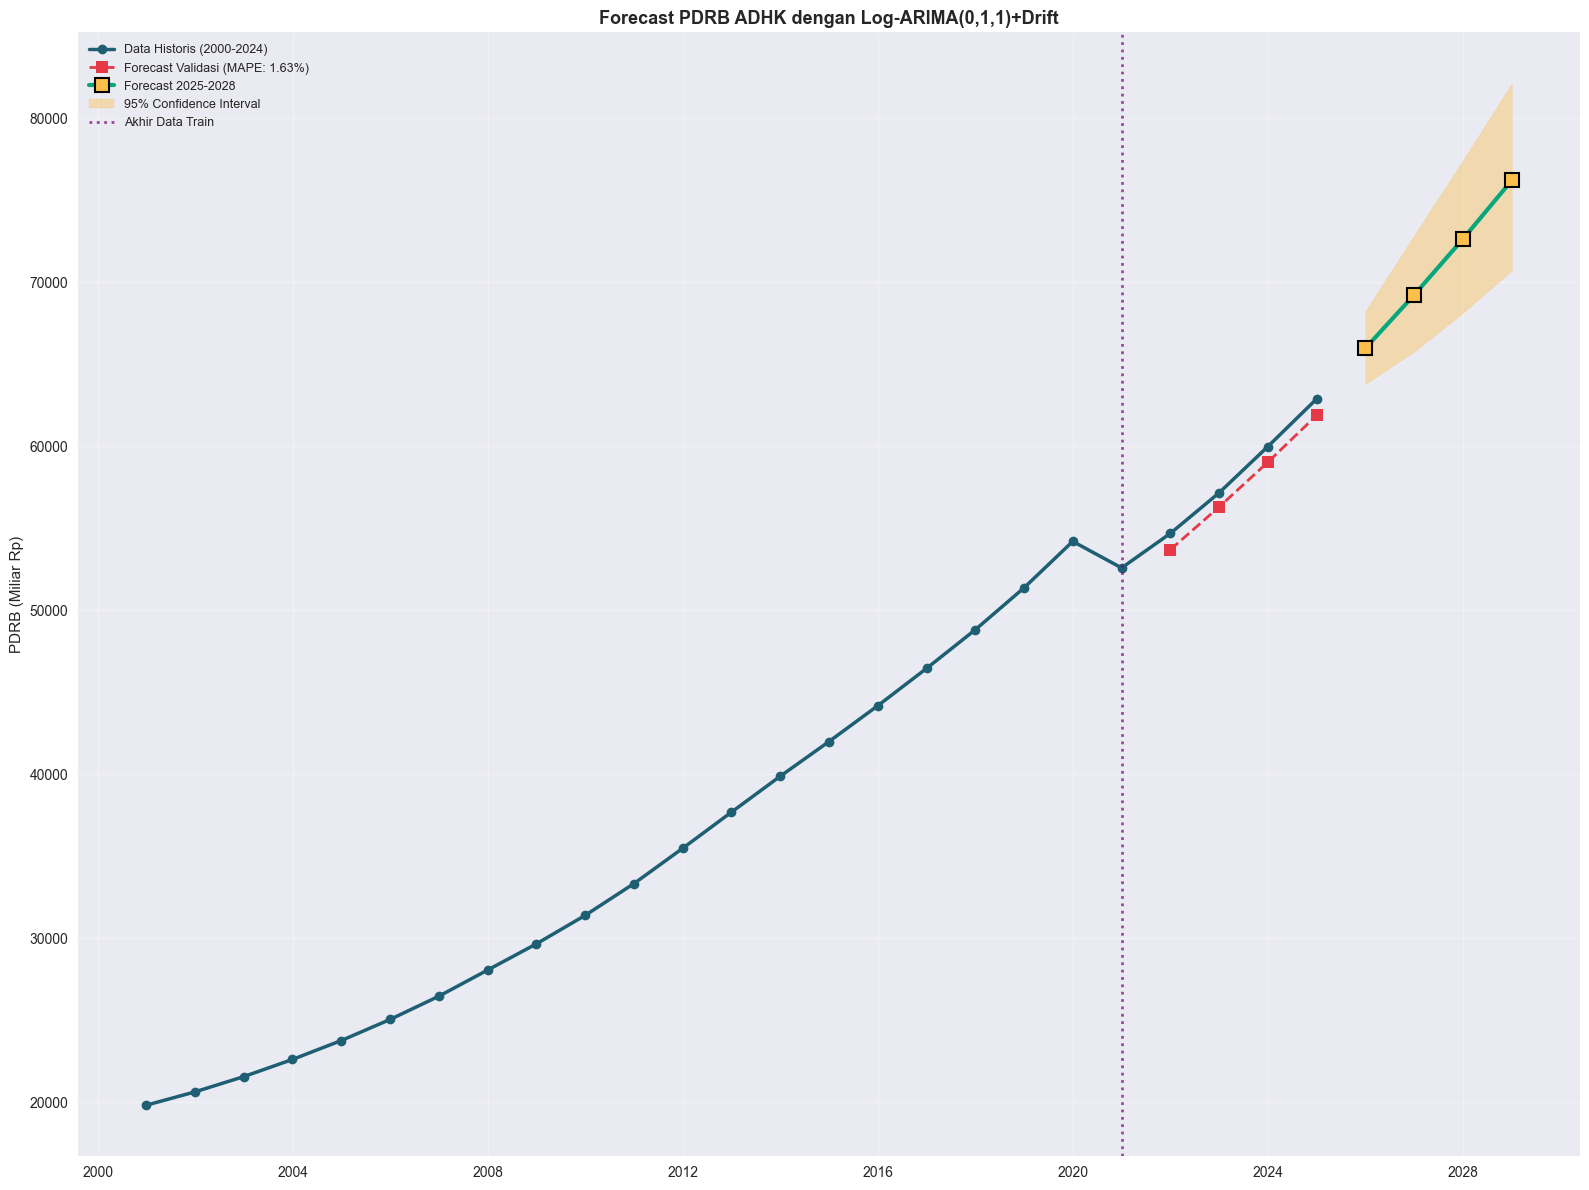

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(16, 12))
# Plot 1: Data Historis + Forecast
axes.plot(df.index, df['PDRB'], 'o-', label='Data Historis (2000-2024)', 
          linewidth=2.5, markersize=7, color='#1E5F74')
axes.plot(test.index, forecast_original, 's--', label=f'Forecast Validasi (MAPE: {mape_test:.2f}%)', 
          linewidth=2, markersize=8, color='#E63946')
axes.plot(pd.date_range('2025-12-31', periods=4, freq='YE'), 
          forecast_mean, 's-', label='Forecast 2025-2028', 
          linewidth=3, markersize=10, color='#06A77D', 
          markerfacecolor='#FCBF49', markeredgecolor='black', markeredgewidth=1.5)
axes.fill_between(pd.date_range('2025-12-31', periods=4, freq='YE'),
                  forecast_ci_lower, forecast_ci_upper, 
                  color='#FCBF49', alpha=0.4, label='95% Confidence Interval')
axes.axvline(x=pd.Timestamp('2020-12-31'), color='purple', linestyle=':', 
             linewidth=2, alpha=0.7, label='Akhir Data Train')
axes.set_title('Forecast PDRB ADHK dengan Log-ARIMA(0,1,1)+Drift', 
               fontsize=13, fontweight='bold')
axes.set_ylabel('PDRB (Miliar Rp)', fontsize=11)
axes.legend(fontsize=9, loc='upper left')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
